### INTRODUÇÃO

O dataset EU Email Communication Network representa interações de e-mail dentro de uma instituição de pesquisa europeia. Cada vértice representa um endereço de e-mail e cada aresta direcionada indica que um usuário enviou ao menos uma mensagem para outro.

Formalmente, o grafo é definido como 

G=(V,E), onde V é o conjunto de vértices (endereços de e-mail) e 

E⊆V×V representa pares ordenados 

(i,j) tais que o usuário i enviou um e-mail para o usuário j.

No arquivo de dados, cada linha contém dois identificadores inteiros representando um par origem-destino, ou seja, uma aresta direcionada da rede. 

Dessa forma, o grafo é caracterizado como:
direcionado
não ponderado(não consideramos número de mensagens)
estático(a dimensão temporal não é modelada)


In [1]:
from requests import get
from gzip import decompress
import re
import numpy as np
import powerlaw
import matplotlib.pyplot as plt
import math

from digraph import Digraph

print("puxando dados........")
response = get("https://snap.stanford.edu/data/email-EuAll.txt.gz")

if (not response.ok):
    print("error ao obter dados........")
    exit()

print("dados recebidos com sucesso!!!")
entrada = decompress(response.content).decode("utf-8")

dados = (list(map(int, re.findall(r"\d+", entrada))))[2:]

puxando dados........
dados recebidos com sucesso!!!


In [2]:

print("gerando grafo........")
V = dados.pop(0)
E = dados.pop(0)

D = Digraph(V)
for _ in range(E):
    v = dados.pop(0)
    w = dados.pop(0)
    D.add_edge(v, w)


gerando grafo........


In [3]:
print(f"Ordem |V|: {D.V}")
print(f"Tamanho |E|: {D.E}") 
    
# calculo do grau médio de grafo direcionado
# d(xi) = | d⁺(xi) + d⁻(xi) |
# d(G) = 1/|V| * sum{i=0,V}(d(xi))

somatorio = 0
for i in range(D.V):
    somatorio += D.degree(i)
grau_medio = somatorio/D.V

print(f"Grau Médio d(G): {grau_medio:.4f}")
print(f"Densidade ⍴: {(E/(V*(V-1))):.15f}")

# calculo do cluster medio
def cluster_local(G, v):
    vizinhos = [i for i in G.adj[v]]
    k = len(vizinhos)

    if k < 2:
        return 0

    links = 0
    for u in vizinhos:
        for w in vizinhos:
            if u != w and w in [i for i in G.adj[u]]:
                links += 1

    return links / (k * (k-1))

somatorio = 0.0
for i in range(D.V):
    somatorio += cluster_local(D, i)

cluster_medio = somatorio / D.V

print(f"Cluster Médio ⍴: {cluster_medio:.10f}")

Ordem |V|: 265214
Tamanho |E|: 420045
Grau Médio d(G): 3.1676
Densidade ⍴: 0.000005971790528
Cluster Médio ⍴: 0.0487213913


                                                                    

##### ANÁLISE EXPLORATORIA DAS MÉTRICAS:

Densidade:
Observa-se que a rede possui densidade muito baixa, indicando que apenas uma pequena fração das conexões possíveis entre usuários realmente ocorre. Esse comportamento é típico de redes sociais e redes de comunicação, nas quais os indivíduos interagem apenas com um subconjunto limitado de participantes.


Grau médio:
Cada usuário envia emails para aproximadamente 3 pessoas em média.
O baixo grau médio indica que a comunicação ocorre principalmente dentro de pequenos grupos ou contatos recorrentes, característica comum em redes organizacionais.


Cluster médio:
Isso significa que existe alguma formação de triângulos.
O coeficiente de clusterização indica presença de grupos locais de comunicação, possivelmente associados a equipes de pesquisa, departamentos ou projetos colaborativos.


Text(0.5, 1.0, 'Histograma dos Valores')

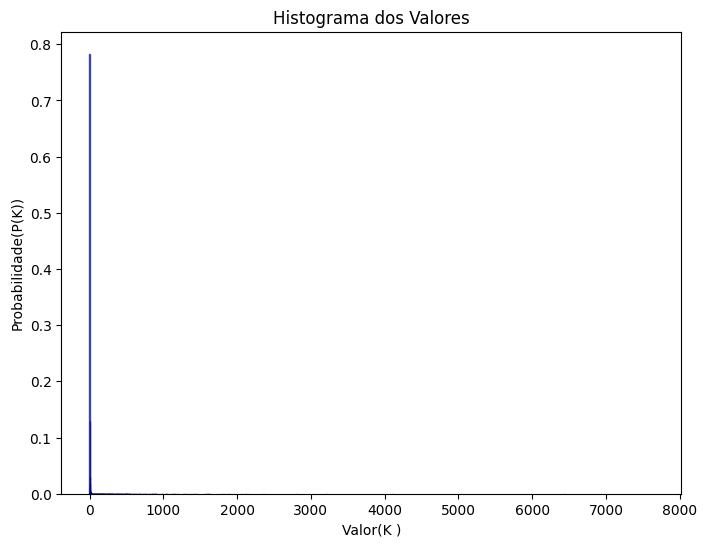

In [4]:

frequencia_absoluta = {}
total_vertices = D.V
    
for v in range(D.V):
    grau_total = D.degree(v)
    if grau_total in frequencia_absoluta:
        frequencia_absoluta[grau_total] += 1
    else:
        frequencia_absoluta[grau_total] = 1
    
    
dados = []
for grau in sorted(frequencia_absoluta.keys()):
    freq_abs = frequencia_absoluta[grau]
    probabilidade = freq_abs / total_vertices  # P(K)
    dados.append([float(grau), probabilidade])

x = [float(row[0]) for row in dados]
y = [float(row[1]) for row in dados] 
plt.figure(figsize=(8, 6))
plt.bar(x, y, width=8, alpha=0.7, color='skyblue', edgecolor='navy')
plt.xlabel('Valor(K )')
plt.ylabel('Probabilidade(P(K))')
plt.title('Histograma dos Valores')


Text(0.5, 1.0, 'Gráfico de Dispersão de Log(K) vs Log(P(K))')

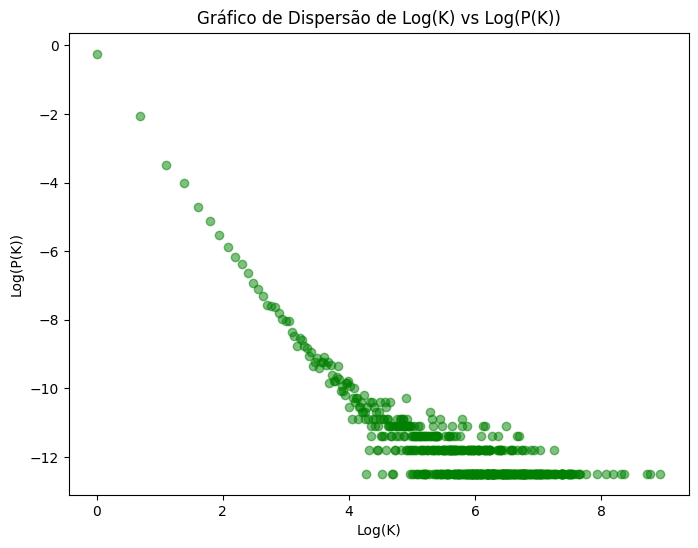

In [5]:
x = [math.log(float(row[0])) for row in dados]
y = [math.log(float(row[1])) for row in dados]
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='green', alpha=0.5)
plt.xlabel('Log(K)')
plt.ylabel('Log(P(K))')
plt.title('Gráfico de Dispersão de Log(K) vs Log(P(K))')

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 600/600 [00:04<00:00, 129.03it/s]


Parâmetro alpha: 2.448594667177434
Valor mínimo: 3.0


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\powerlaw\distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Text(0.5, 1.0, 'Análise de Lei de Potência')

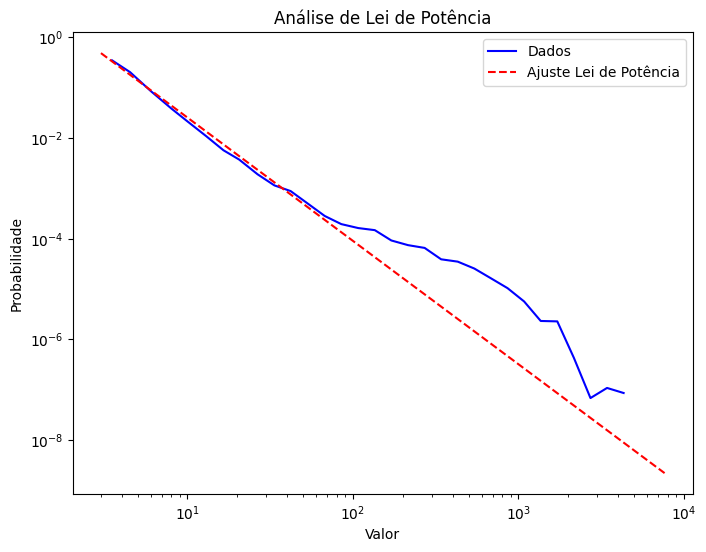

In [6]:
valores = [D.degree(i) for i in range(D.V)]
fit = powerlaw.Fit(valores)
print(f"Parâmetro alpha: {fit.alpha}")
print(f"Valor mínimo: {fit.xmin}")
plt.figure(figsize=(8, 6))
fit.plot_pdf(color='b', label='Dados')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Ajuste Lei de Potência')
plt.xlabel('Valor')
plt.ylabel('Probabilidade')
plt.legend()
plt.title('Análise de Lei de Potência')
       

### Análise da distribuição de graus

Distribuição de graus

enorme concentração de nós com grau baixo
poucos nós com grau extremamente alto
Isso caracteriza uma distribuição heavy-tailed.
A distribuição de graus apresenta forte assimetria, com predominância de vértices de baixo grau e presença de poucos vértices altamente conectados. Esse comportamento é típico de redes sociais e de comunicação.  

Gráfico log-log

tendência aproximadamente linear na região intermediária
ruído na cauda
A visualização da distribuição de graus em escala log-log sugere comportamento aproximadamente linear em parte da distribuição, indicando possível compatibilidade com um modelo de lei de potência.


Ajuste por lei de potência

A equação usada:
P(k)∼k^−α
O modelo de lei de potência descreve sistemas nos quais poucos vértices concentram grande parte das conexões, fenômeno associado à presença de hubs.

### A Rede é Scale-free?

Embora a distribuição apresente cauda pesada e comportamento compatível com lei de potência (α = 2,4), a classificação da rede como "scale-free" só deve ser feita depois que se determinar se existe uma preferência na hora de anexamento (preferential attachment). Como se trata de uma situação de e-mails e o uso deles está associado aos meios corporativos, os hubs se formaram no núcleo das empresas, fazendo assim com que novos e-mails (arestas) sejam associados a hubs já existentes, podendo-se, então, classificar a rede como "scale-free".




### INTERPRETAÇÃO DO DOMÍNIO

Em redes de comunicação organizacional, alguns indivíduos atuam como centros de disseminação de informação, como administradores, coordenadores ou pesquisadores seniores. Esses indivíduos tendem a apresentar maior conectividade, funcionando como hubs estruturais na rede.

### REFERENCIAS

LESKOVEC, J. EU email communication network. Stanford Network Analysis Project (SNAP). Disponível em: https://snap.stanford.edu/data/email-EuAll.html Acesso em: 9 mar. 2026.

GOLDBARG, Marco; GOLDBARG, Elizabeth. Grafos: conceitos, algoritmos e aplicações. Rio de Janeiro: Elsevier, 2012. 1 recurso online. ISBN 9788595155756